In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

FIG_WIDTH = 6
FIG_HEIGHT = 4
TICK_FONTSIZE = 6
AXIS_FONTSIZE = 10

sns.set_theme(context='notebook', style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': AXIS_FONTSIZE,
    'xtick.labelsize': TICK_FONTSIZE,
    'ytick.labelsize': TICK_FONTSIZE,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
from pathlib import Path

from hierarchical_ranking.task_level_ranking import (
    calc_paired_tests,
    ranking_from_multiple_paired_tests,
    pivot_scores_by_model,
)
from hierarchical_ranking.ranking_measures import (
    calc_interval_width, 
    get_top_k, 
    L_U_to_CI
)
from hierarchical_ranking.plot_ranks import plot_ranks_intervals
from hierarchical_ranking.conformal_interval_aggregation import (
    merge_intervals_union, 
    merge_intervals_quantile
)

In [2]:
filename = 'data/tabarena_results.csv'
data_path = Path(filename)
if not data_path.is_file():
    print(
        f'File not found: {data_path.resolve()}\n\n'
        'Download the TabArena benchmark data first:\n\n'
        'python data/download_data.py tabarena\n\n'
    )
    raise FileNotFoundError(data_path)

In [3]:
tabarena_data = pd.read_csv(data_path)
tabarena_data.head()

,dataset,model,fold,problem_type,config_type,performance_score
0,APSFailure,CAT (D),0,binary,CAT,0.006103
1,APSFailure,CAT (D),1,binary,CAT,0.009555
2,APSFailure,CAT (D),2,binary,CAT,0.007709
3,APSFailure,CAT (D),3,binary,CAT,0.013824
4,APSFailure,CAT (D),4,binary,CAT,0.005124


In [4]:
score_col = 'performance_score'
model_col = 'model'
dataset_col = 'dataset'

all_datasets = tabarena_data[dataset_col].unique()
all_models = tabarena_data[model_col].unique()
print('Number of models: ', len(all_models))
print('Number of datasets: ', len(all_datasets))

Number of models:  44
Number of datasets:  51


# Tabarena leaderboard V0.1

In [5]:
tabarena_ldb = pd.read_csv('data/tabarena_leaderboard_v01.csv')
tabarena_ldb.head()

,model,elo,elo-,elo+
0,REALMLP (T+E),1564,57,73
1,TABM_GPU (T+E),1541,61,74
2,GBM (T+E),1527,45,49
3,CAT (T+E),1482,55,57
4,CAT (T),1469,49,56


In [6]:
print('Number of models: ', tabarena_ldb['model'].nunique())

Number of models:  44


# Overview

## Task-level ranking

The base values are multiple scores (folds) for each model and dataset. The dataset-level rank CIs are costructed from the base values, taking into account both variability between folds, and between models.

In [7]:
alpha_tsk = 0.05
marginal_correction = True
correction_method = 'holm'

### Construct dataset-level CIs

In the paired t-test, the hypothesis direction should reflect the relationship between the tasks. We assume a higher rank is better, but in raw scores, higher or lower scores may indicate better performance. In the TabArena example, a lower score indicates better performance. Therefore, setting `alternative='greater'` ensures better models are ranked higher.

In [8]:
all_paired_test_res = {}
all_ranks_intervals = {}
for d in all_datasets:
    df = tabarena_data[tabarena_data[dataset_col] == d].reset_index(drop=True)
    base_values = pivot_scores_by_model(df, 'fold', model_col, score_col)
    paired_test_res = calc_paired_tests({'data': base_values}, from_summary=False, 
                                         test_func_name='ttest', alternative='greater')
    all_paired_test_res[d] = paired_test_res
    ranks = ranking_from_multiple_paired_tests(paired_test_res, 
                                               alpha=alpha_tsk, 
                                               marginal_correction=marginal_correction,
                                               correction_method=correction_method)
    all_ranks_intervals[d] = ranks

### Examples

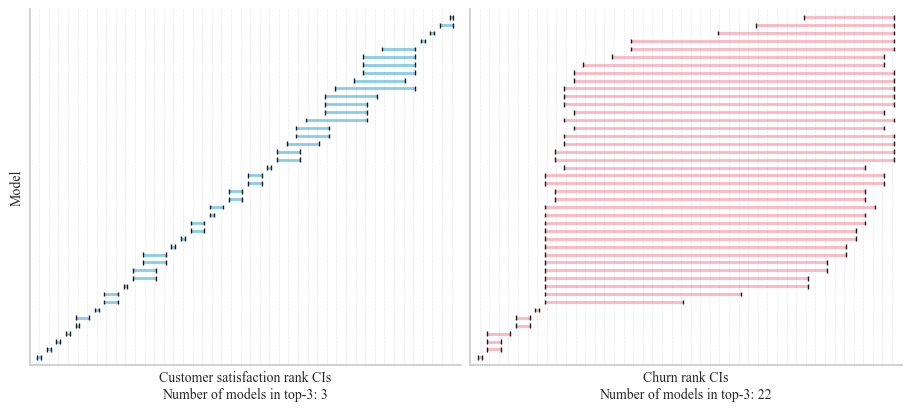

In [9]:
datasets_info = {'customer_satisfaction_in_airline': {'name': 'Customer satisfaction' , 'color': 'skyblue'},
                 'churn': {'name': 'Churn', 'color': 'lightpink'}}

fig, axs = plt.subplots(1, 2, figsize=(1.5 * FIG_WIDTH, FIG_HEIGHT), sharey=True, layout='constrained')
for i, d in enumerate(datasets_info.keys()):
    plot_ranks_intervals(all_ranks_intervals[d], show_axis_labels=False, ax=axs[i], 
                         default_color=datasets_info[d]['color'],
                         labels_fontsize=TICK_FONTSIZE,
                         axis_fontsize=AXIS_FONTSIZE)
    top_3 = get_top_k(all_ranks_intervals[d], 3)
    axs[i].set_ylim(0, len(all_models) + 1)
    axs[i].set_xlabel(datasets_info[d]['name'] + ' rank CIs\n' + 
                     'Number of models in top-3: ' + str(len(top_3)),
                      fontsize=AXIS_FONTSIZE)
axs[1].set_ylabel('');

## Leaderboard-level ranking

### Elo scores with CIs for the scores

In [10]:
elo_sorted_models = tabarena_ldb.sort_values('elo', ascending=True)['model'].tolist()
elo_df = tabarena_ldb.set_index('model').loc[elo_sorted_models]
_default_color = 'gray'
model_type_colors = {
    model: 'tab:green' if model.startswith('CAT')
    else 'tab:orange' if model.startswith('KNN')
    else _default_color
    for model in elo_df.index
}
model_label_colors = {
    model: color if color != _default_color else 'black'
    for model, color in model_type_colors.items()
}

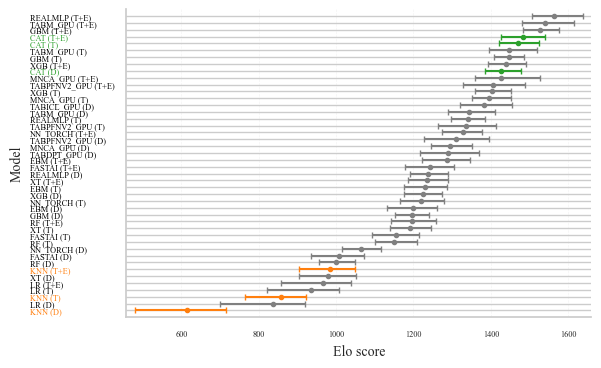

In [11]:
y = np.arange(1, len(elo_df) + 1)
x_vals = pd.to_numeric(elo_df['elo'], errors='coerce').to_numpy(dtype=float)
xerr_lo = pd.to_numeric(elo_df['elo-'], errors='coerce').to_numpy(dtype=float)
xerr_hi = pd.to_numeric(elo_df['elo+'], errors='coerce').to_numpy(dtype=float)

fig_elo, ax_elo = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
for i, name in enumerate(elo_df.index):
    ax_elo.errorbar(
        x_vals[i], y[i], xerr=([xerr_lo[i]], [xerr_hi[i]]),
        fmt='o', markersize=3, elinewidth=1.5, capsize=2,
        color=model_type_colors[name],
    )

ax_elo.set_ylim(0, len(elo_df) + 1)
ax_elo.margins(x=0.02)
ax_elo.set(xlabel='Elo score', ylabel='Model')
ax_elo.tick_params(axis='both', labelsize=TICK_FONTSIZE)
ax_elo.xaxis.label.set_size(AXIS_FONTSIZE)
ax_elo.yaxis.label.set_size(AXIS_FONTSIZE)
ax_elo.grid(axis='x', alpha=0.2, linestyle='--', linewidth=0.5)
ax_elo.set_yticks(y, labels=elo_df.index)
for tick, name in zip(ax_elo.get_yticklabels(), elo_df.index):
    tick.set_horizontalalignment('left')
    tick.set_x(-0.18)
    tick.set_color(model_label_colors[name])

In [12]:
alpha_ldb = 0.5
ranks_intervals_collection = pd.concat({k: L_U_to_CI(v) for k, v in all_ranks_intervals.items()}, axis=1)

### Quantile

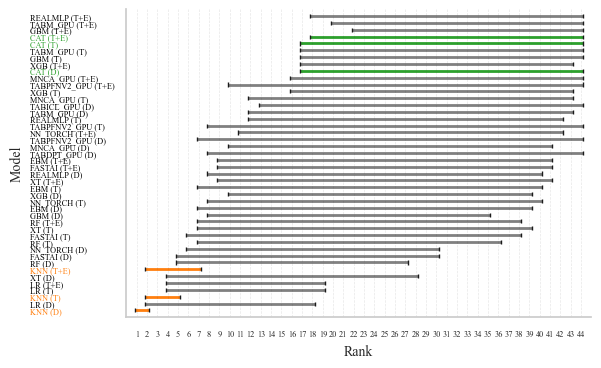

In [13]:
quantile_intervals = merge_intervals_quantile(ranks_intervals_collection, alpha_ldb=alpha_ldb)

fig_q, ax_q = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
quantile_for_plot = quantile_intervals.loc[elo_sorted_models]
plot_ranks_intervals(
    quantile_for_plot,
    ax=ax_q,
    fixed_order=elo_sorted_models,
    colors_map=model_type_colors,
    labels_fontsize=TICK_FONTSIZE,
    axis_fontsize=AXIS_FONTSIZE,
    align_labels='left',
    color_labels=True,
    label_colors_map=model_label_colors,
);

### Union

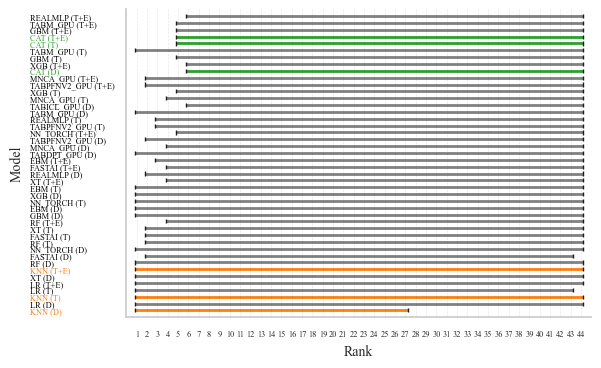

In [14]:
union_intervals = merge_intervals_union(ranks_intervals_collection)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
union_for_plot = union_intervals.loc[elo_sorted_models]
plot_ranks_intervals(
    union_for_plot,
    ax=ax,
    fixed_order=elo_sorted_models,
    colors_map=model_type_colors,
    labels_fontsize=TICK_FONTSIZE,
    axis_fontsize=AXIS_FONTSIZE,
    align_labels='left',
    color_labels=True,
    label_colors_map=model_label_colors,
);

# Tree-based regression models

In [15]:
tree_types = ['CAT', 'XT', 'XGB', 'RF', 'EBM', 'GBM']
tree_models = tabarena_data[tabarena_data['config_type'].isin(tree_types)]['model'].unique()
datasets_regression = tabarena_data[tabarena_data['problem_type'] == 'regression']['dataset'].unique()

In this analysis, we filtered the datasets and models, using only a subset of the pairwise comparisons from the full setup. There is no need to recompute the p-values. However, the correction for multiple comparisons and the construction of rank intervals must be repeated, since the family of hypotheses has changed. Likewise, if a new dataset or model is added to the benchmark, we can simply include the new p-values and reconstruct the rank intervals as needed.

In [16]:
regression_ranks_intervals = {}
for d in datasets_regression:
    paired_test_res = all_paired_test_res[d][(all_paired_test_res[d]['candidate_1'].isin(tree_models) 
                                              & all_paired_test_res[d]['candidate_2'].isin(tree_models))]
    ranks = ranking_from_multiple_paired_tests(paired_test_res, 
                                               alpha=alpha_tsk, 
                                               marginal_correction=marginal_correction,
                                               correction_method=correction_method)
    regression_ranks_intervals[d] = L_U_to_CI(ranks)

In [17]:
regression_ranks_intervals_collection = pd.concat(regression_ranks_intervals, axis=1)
regression_quantile_intervals = merge_intervals_quantile(regression_ranks_intervals_collection, alpha_ldb=alpha_ldb)
regression_width_quantile = calc_interval_width(lowers=regression_quantile_intervals['L'], uppers=regression_quantile_intervals['U'])

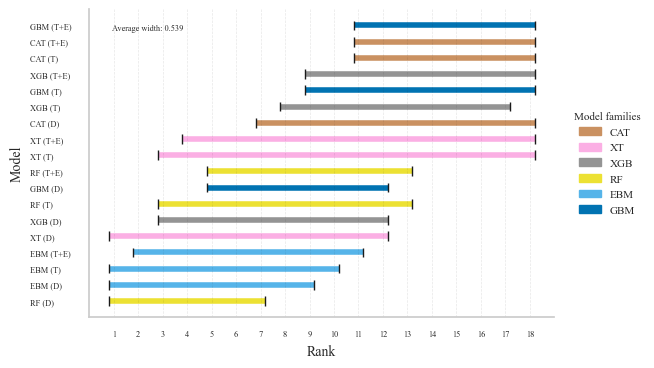

In [18]:
# color models by families
family_colors = sns.color_palette('colorblind', n_colors=len(tree_types) + 10)
family_colors = {model: family_colors[i + 5] for i, model in enumerate(tree_types)}
model_colors = {model: family_colors[model.split(' ')[0]] for model in regression_quantile_intervals.index}

legend_dict = {'handles': [], 'labels': [], 'title': 'Model families'}
for model, color in family_colors.items():
    legend_dict['handles'].append(mpatches.Patch(color=color, label=model))
    legend_dict['labels'].append(model)
legend_dict['title'] = 'Model families'

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
plot_ranks_intervals(regression_quantile_intervals, 
                     interval_width=regression_width_quantile, 
                     colors_map=model_colors, 
                     legend_dict=legend_dict,
                     legend_loc='center left',
                     bbox_to_anchor=(1.02, 0.5),
                     legend_frameon=False,
                     ax=ax,
                     linewidth=4,
                     align_labels='left',
                     align_margin=0.1,
                     labels_fontsize=TICK_FONTSIZE,
                     axis_fontsize=AXIS_FONTSIZE);

# Model intervals across datasets

Distribution of dataset rank CIs for two models that share the same rank PI.

In [19]:
# create here a dataset-problem type map
dataset_problem_map = (
    tabarena_data.groupby('dataset', sort=True)['problem_type'].first().sort_index()
)
# Color map: one color per problem_type; all datasets with that type share it.
problem_types_sorted = sorted(dataset_problem_map.unique())
_palette = sns.color_palette('colorblind', n_colors=max(len(problem_types_sorted), 3))
problem_type_color = {
    pt: _palette[i % len(_palette)] for i, pt in enumerate(problem_types_sorted)
}
dataset_colors = {
    ds: problem_type_color[pt] for ds, pt in dataset_problem_map.items()
}
legend_dict = {
    'handles': [
        mpatches.Patch(color=problem_type_color[pt], label=pt)
        for pt in problem_types_sorted
    ],
    'labels': list(problem_types_sorted),
    'title': 'Problem type',
}
models_info = {'REALMLP (T+E)': {'name': 'A'},
                 'CAT (T+E)': {'name': 'B'}}

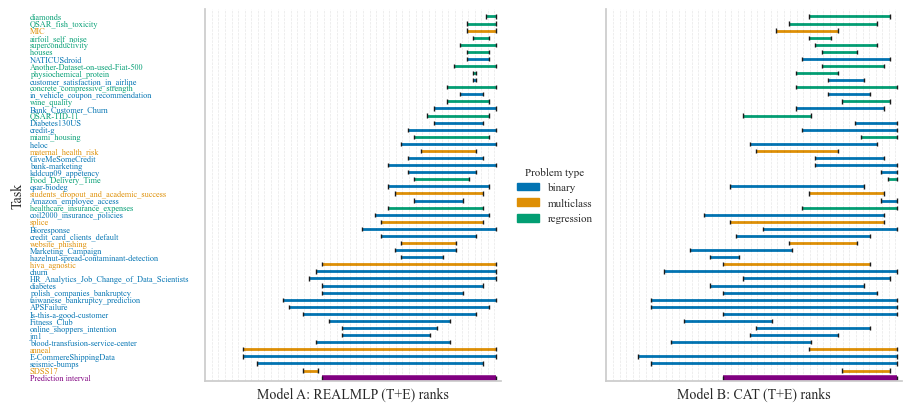

In [20]:
def task_intervals(model):
    s = ranks_intervals_collection.loc[model]
    return pd.DataFrame(list(s), index=s.index, columns=['L', 'U'])

ref = task_intervals(next(iter(models_info)))
task_order = (
    ref.assign(_m=(ref['L'] + ref['U']) / 2, _w=ref['U'] - ref['L'])
    .sort_values(['_m', '_w'])
    .index.tolist()
)
fig_paired, axs = plt.subplots(
    1, len(models_info), figsize=(1.5 * FIG_WIDTH, FIG_HEIGHT), sharey=True, layout='constrained',
)
for idx, (model, info) in enumerate(models_info.items()):
    plot_ranks_intervals(
        task_intervals(model),
        ax=np.atleast_1d(axs)[idx],
        fixed_order=task_order,
        ylabel='Task' if idx == 0 else '',
        xlabel=f'Model {info['name']}: {model} ranks',
        max_xtick=len(all_models),
        colors_map=dataset_colors,
        prediction_interval=quantile_intervals.loc[model, ['L', 'U']].tolist(),
        legend_dict=legend_dict if idx == 0 else None,
        legend_loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        legend_frameon=False,
        show_xticklabels=False,
        show_yticklabels=idx == 0,
        show_candidate_yticklabels=True,
        align_labels='left',
        align_margin=0.55,
        color_labels=True,
        label_colors_map=dataset_colors,
        labels_fontsize=TICK_FONTSIZE,
        axis_fontsize=AXIS_FONTSIZE,
    )